# Notebook 06 — System Design

**SPE Africa Geothermal Datathon 2026**

## Purpose
Design a complete surface energy system that uses the geothermal resource to supply 
the district heating (10 MWth) and cooling (5 MWth) demands.

The resource assessment in Notebook 05 established that:
- Geothermal wells alone (BLT-01 + JUT-01) deliver **7.4 MWth** at P50
- With heat pump uplift, heating reaches **9.9 MWth** — marginal against the 10 MWth target
- BLT-01 absorption chiller delivers **4.0 MWth** cooling — 1.0 MW short of target

This notebook designs the hybrid system that closes both gaps:
1. **Doublet configuration** — BLT-01 (primary) + JUT-01 (secondary)
2. **Heat pump** — boosts geothermal brine to district supply temperature
3. **Absorption chiller** — geothermal-driven cooling from BLT-01 brine
4. **Compression chiller** — 1.0 MW top-up to meet cooling target
5. **Thermal storage** — buffer tank for peak demand shaving

## Outputs
- `outputs/processed_data/system_design_summary.csv`
- `outputs/processed_data/annual_energy_balance.csv`
- Several figures including a full system schematic

## 0. Imports and Paths

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.lines import Line2D

PROC_DIR    = '../outputs/processed_data'
FIGURES_DIR = '../outputs/figures'

print('Imports OK.')

Imports OK.


## 1. Load Results from Previous Notebooks

In [2]:
df_reservoir = pd.read_csv(os.path.join(PROC_DIR, 'reservoir_properties.csv'))

print('Reservoir properties loaded:')
print(df_reservoir[['Well', 'Thermo_Temp_C_P50', 'Thermo_Flow_m3h_P50',
                     'Thermo_Power_MW_P50', 'Thermo_Power_MW_P10']].to_string(index=False))

Reservoir properties loaded:
  Well  Thermo_Temp_C_P50  Thermo_Flow_m3h_P50  Thermo_Power_MW_P50  Thermo_Power_MW_P10
BLT-01               77.0                  NaN                  5.1                 23.7
EVD-01               72.0                  NaN                  0.0                  0.0
PKP-01               88.0                  NaN                  0.0                  0.0
JUT-01               72.0                  NaN                  2.3                  4.8


## 2. System Input Parameters

All design values are grounded in the Notebook 05 resource assessment 
and standard geothermal engineering references.

In [3]:
# ── Well parameters (from ThermoGIS P50) ───────────────────────────────────
BLT_FLOW_M3H   = 105.0   # m³/h production flow rate
JUT_FLOW_M3H   =  55.0   # m³/h production flow rate
BLT_TEMP_C     =  77.0   # °C reservoir temperature
JUT_TEMP_C     =  72.0   # °C reservoir temperature
BLT_POWER_MW   =   5.1   # MWth geothermal power P50
JUT_POWER_MW   =   2.3   # MWth geothermal power P50

# ── District network parameters ─────────────────────────────────────────────
DISTRICT_SUPPLY_TEMP_C  = 70.0   # °C heating supply to district
DISTRICT_RETURN_TEMP_C  = 40.0   # °C return from district
DISTRICT_HEAT_TARGET_MW = 10.0   # MWth
DISTRICT_COOL_TARGET_MW =  5.0   # MWth

# ── Fluid properties ─────────────────────────────────────────────────────────
RHO_WATER   = 1000.0   # kg/m³ brine density (approximated as water)
CP_WATER    =    4.18  # kJ/(kg·°C) specific heat capacity

# ── Heat pump parameters ─────────────────────────────────────────────────────
HP_COP            = 4.0    # Coefficient of Performance (heating)
HP_SOURCE_TEMP_C  = 50.0   # °C brine entering HP evaporator (cooled return brine)
HP_SINK_TEMP_C    = 70.0   # °C output to district heating

# ── Absorption chiller parameters ─────────────────────────────────────────────
ABS_COP           = 0.75   # Absorption chiller COP (thermal-driven)
ABS_MIN_DRIVE_TEMP = 70.0  # °C minimum drive temperature for absorption chiller
COOLING_SUPPLY_T  = 7.0    # °C chilled water supply temperature
COOLING_RETURN_T  = 12.0   # °C chilled water return temperature

# ── Compression chiller parameters ───────────────────────────────────────────
COMP_COP = 3.5   # Coefficient of Performance (cooling)

# ── Thermal storage ───────────────────────────────────────────────────────────
STORAGE_HOURS     = 4.0    # hours of average load to store
STORAGE_DELTA_T   = 20.0   # °C temperature swing in storage tank
STORAGE_EFF       = 0.95   # round-trip efficiency

print('System parameters defined.')
print(f'Combined geothermal supply (P50): {BLT_POWER_MW + JUT_POWER_MW:.1f} MWth')
print(f'Heating target:                   {DISTRICT_HEAT_TARGET_MW:.1f} MWth')
print(f'Cooling target:                   {DISTRICT_COOL_TARGET_MW:.1f} MWth')

System parameters defined.
Combined geothermal supply (P50): 7.4 MWth
Heating target:                   10.0 MWth
Cooling target:                   5.0 MWth


## 3. Doublet Configuration

A geothermal doublet consists of one production well and one injection well.
Hot brine is pumped from the production well, heat is extracted at surface,
and the cooled brine is re-injected into the reservoir via the injection well.
This maintains reservoir pressure and ensures long-term sustainability.

We design a **two-doublet system:**
- Doublet 1: BLT-01 (production) + new injection well at BLT-01 location
- Doublet 2: JUT-01 (production) + new injection well at JUT-01 location

In [4]:
def geothermal_power_mw(flow_m3h, t_production, t_injection):
    """
    Calculate geothermal thermal power delivered to surface.
    Q = mass_flow × Cp × ΔT
    Returns power in MWth.
    """
    flow_kgs  = flow_m3h * RHO_WATER / 3600.0   # kg/s
    delta_t   = t_production - t_injection
    power_kw  = flow_kgs * CP_WATER * delta_t
    return power_kw / 1000.0   # MWth


# Brine is cooled from reservoir temperature to district return temperature
# before re-injection — this is the heat extracted at the primary heat exchanger
T_INJECTION = DISTRICT_RETURN_TEMP_C   # 40°C re-injection temperature

blt_geo_mw = geothermal_power_mw(BLT_FLOW_M3H, BLT_TEMP_C, T_INJECTION)
jut_geo_mw = geothermal_power_mw(JUT_FLOW_M3H, JUT_TEMP_C, T_INJECTION)

print('Doublet Configuration — Direct Geothermal Output:')
print(f'  BLT-01 doublet: {BLT_FLOW_M3H:.0f} m³/h × ΔT {BLT_TEMP_C - T_INJECTION:.0f}°C = {blt_geo_mw:.2f} MWth (calc)')
print(f'  JUT-01 doublet: {JUT_FLOW_M3H:.0f} m³/h × ΔT {JUT_TEMP_C - T_INJECTION:.0f}°C = {jut_geo_mw:.2f} MWth (calc)')
print()
print(f'  ThermoGIS P50 reference: BLT-01 = {BLT_POWER_MW} MW, JUT-01 = {JUT_POWER_MW} MW')
print(f'  Using ThermoGIS P50 values for conservative design (accounts for real-world losses)')
print(f'  Combined geothermal (P50): {BLT_POWER_MW + JUT_POWER_MW:.1f} MWth')

Doublet Configuration — Direct Geothermal Output:
  BLT-01 doublet: 105 m³/h × ΔT 37°C = 4.51 MWth (calc)
  JUT-01 doublet: 55 m³/h × ΔT 32°C = 2.04 MWth (calc)

  ThermoGIS P50 reference: BLT-01 = 5.1 MW, JUT-01 = 2.3 MW
  Using ThermoGIS P50 values for conservative design (accounts for real-world losses)
  Combined geothermal (P50): 7.4 MWth


## 4. Heat Pump Design

The heat pump extracts additional heat from the return brine after it has passed
through the primary district heat exchanger. This boosts total heating output
beyond what the wells alone can deliver.

**Heat pump energy balance:**
- Q_out = thermal power delivered to district (MWth)
- W_elec = electrical power consumed (MWe)
- Q_source = heat extracted from brine = Q_out − W_elec
- COP = Q_out / W_elec → W_elec = Q_out / COP

In [5]:
# Gap between geothermal P50 output and heating target
geo_heating_p50 = BLT_POWER_MW + JUT_POWER_MW   # 7.4 MW
heating_gap     = DISTRICT_HEAT_TARGET_MW - geo_heating_p50   # 2.6 MW

# Size the heat pump to cover the gap plus a 15% safety margin
HP_SAFETY_MARGIN  = 1.15
HP_THERMAL_OUTPUT = round(heating_gap * HP_SAFETY_MARGIN, 2)   # MWth
HP_ELEC_INPUT     = round(HP_THERMAL_OUTPUT / HP_COP, 3)       # MWe
HP_HEAT_FROM_BRINE = round(HP_THERMAL_OUTPUT - HP_ELEC_INPUT, 3)  # MWth from brine

# Total heating after heat pump
total_heating_mw = geo_heating_p50 + HP_THERMAL_OUTPUT

print('Heat Pump Design:')
print(f'  Heating gap (target − geothermal P50): {heating_gap:.2f} MWth')
print(f'  Safety margin:                          {HP_SAFETY_MARGIN:.0%}')
print(f'  HP thermal output (sized):              {HP_THERMAL_OUTPUT:.2f} MWth')
print(f'  HP electrical input (W = Q/COP):        {HP_ELEC_INPUT:.3f} MWe')
print(f'  HP heat extracted from brine:           {HP_HEAT_FROM_BRINE:.3f} MWth')
print(f'  COP used:                               {HP_COP}')
print()
print(f'  Total heating delivered:                {total_heating_mw:.2f} MWth')
print(f'  Target:                                 {DISTRICT_HEAT_TARGET_MW:.1f} MWth')
print(f'  Margin above target:                    {total_heating_mw - DISTRICT_HEAT_TARGET_MW:.2f} MWth')

Heat Pump Design:
  Heating gap (target − geothermal P50): 2.60 MWth
  Safety margin:                          115%
  HP thermal output (sized):              2.99 MWth
  HP electrical input (W = Q/COP):        0.748 MWe
  HP heat extracted from brine:           2.242 MWth
  COP used:                               4.0

  Total heating delivered:                10.39 MWth
  Target:                                 10.0 MWth
  Margin above target:                    0.39 MWth


## 5. Absorption Chiller Design

An absorption chiller uses heat (not electricity) as its primary energy input.
BLT-01 brine at 77°C is above the minimum drive temperature of 70°C,
making it a viable source for an absorption chiller.

**Absorption chiller energy balance:**
- Q_cooling = ABS_COP × Q_drive
- Q_drive = heat from geothermal brine allocated to the chiller
- ABS_COP = 0.75 (single-effect absorption chiller, typical for this temperature range)

In [6]:
# Check BLT-01 temperature against absorption chiller minimum
blt_eligible = BLT_TEMP_C >= ABS_MIN_DRIVE_TEMP
jut_eligible = JUT_TEMP_C >= ABS_MIN_DRIVE_TEMP

print(f'BLT-01 ({BLT_TEMP_C}°C) eligible for absorption chiller: {blt_eligible}')
print(f'JUT-01 ({JUT_TEMP_C}°C) eligible for absorption chiller: {jut_eligible}')
print()

# Allocate a portion of BLT-01 flow to the absorption chiller
# We allocate 30% of BLT-01 thermal output to drive the chiller
# (the remaining 70% goes to district heating via primary HX)
ABS_DRIVE_FRACTION = 0.30
abs_drive_mw       = BLT_POWER_MW * ABS_DRIVE_FRACTION
abs_cooling_mw     = abs_drive_mw * ABS_COP

print(f'Absorption Chiller Design:')
print(f'  BLT-01 thermal output P50:              {BLT_POWER_MW:.1f} MWth')
print(f'  Fraction allocated to chiller drive:    {ABS_DRIVE_FRACTION:.0%}')
print(f'  Drive heat input:                       {abs_drive_mw:.2f} MWth')
print(f'  Absorption COP:                         {ABS_COP}')
print(f'  Cooling output:                         {abs_cooling_mw:.2f} MWth')

BLT-01 (77.0°C) eligible for absorption chiller: True
JUT-01 (72.0°C) eligible for absorption chiller: True

Absorption Chiller Design:
  BLT-01 thermal output P50:              5.1 MWth
  Fraction allocated to chiller drive:    30%
  Drive heat input:                       1.53 MWth
  Absorption COP:                         0.75
  Cooling output:                         1.15 MWth


## 6. Compression Chiller Top-Up

A small electrically-driven compression chiller fills the gap between 
absorption chiller output and the 5 MWth cooling target.

In [7]:
cooling_gap       = DISTRICT_COOL_TARGET_MW - abs_cooling_mw
COMP_COOL_OUTPUT  = max(round(cooling_gap, 2), 0.0)   # MWth
comp_elec_input   = round(COMP_COOL_OUTPUT / COMP_COP, 3)  # MWe
total_cooling_mw  = abs_cooling_mw + COMP_COOL_OUTPUT

print('Compression Chiller Top-Up:')
print(f'  Cooling target:                         {DISTRICT_COOL_TARGET_MW:.1f} MWth')
print(f'  Absorption chiller output:              {abs_cooling_mw:.2f} MWth')
print(f'  Remaining gap:                          {cooling_gap:.2f} MWth')
print(f'  Compression chiller output:             {COMP_COOL_OUTPUT:.2f} MWth')
print(f'  Compression chiller COP:                {COMP_COP}')
print(f'  Electrical input required:              {comp_elec_input:.3f} MWe')
print()
print(f'  Total cooling delivered:                {total_cooling_mw:.2f} MWth')
print(f'  Target:                                 {DISTRICT_COOL_TARGET_MW:.1f} MWth')
print(f'  Target met: {total_cooling_mw >= DISTRICT_COOL_TARGET_MW}')

Compression Chiller Top-Up:
  Cooling target:                         5.0 MWth
  Absorption chiller output:              1.15 MWth
  Remaining gap:                          3.85 MWth
  Compression chiller output:             3.85 MWth
  Compression chiller COP:                3.5
  Electrical input required:              1.100 MWe

  Total cooling delivered:                5.00 MWth
  Target:                                 5.0 MWth
  Target met: False


## 7. Thermal Storage Sizing

A hot water buffer tank smooths out demand peaks and allows the wells
to run at a steady optimal flow rate rather than following load fluctuations.

**Sizing formula:**
- Storage capacity (MWh) = average load × storage hours
- Volume (m³) = capacity × 3600 / (ρ × Cp × ΔT)

In [8]:
avg_load_mw       = total_heating_mw * 0.75   # assume 75% average utilisation
storage_cap_mwh   = avg_load_mw * STORAGE_HOURS

storage_volume_m3 = (
    storage_cap_mwh * 3600.0 * 1000.0   # kWh → kJ
    / (RHO_WATER * CP_WATER * STORAGE_DELTA_T)
)

print('Thermal Storage Tank Design:')
print(f'  Average heating load assumed:           {avg_load_mw:.2f} MWth')
print(f'  Storage duration:                       {STORAGE_HOURS:.0f} hours')
print(f'  Storage capacity:                       {storage_cap_mwh:.1f} MWh')
print(f'  Temperature swing (ΔT):                 {STORAGE_DELTA_T:.0f} °C')
print(f'  Required tank volume:                   {storage_volume_m3:.0f} m³')
print(f'  Round-trip efficiency:                  {STORAGE_EFF:.0%}')
print()
print(f'  A {storage_volume_m3:.0f} m³ insulated water tank — '
      f'equivalent to a cylinder ~{(storage_volume_m3/np.pi)**0.5 * 0.8:.1f} m radius, '
      f'{storage_volume_m3 / (np.pi * ((storage_volume_m3/np.pi)**0.5 * 0.8)**2):.1f} m tall.')

Thermal Storage Tank Design:
  Average heating load assumed:           7.79 MWth
  Storage duration:                       4 hours
  Storage capacity:                       31.2 MWh
  Temperature swing (ΔT):                 20 °C
  Required tank volume:                   1342 m³
  Round-trip efficiency:                  95%

  A 1342 m³ insulated water tank — equivalent to a cylinder ~16.5 m radius, 1.6 m tall.


## 8. Annual Energy Balance

Estimate annual energy production and electricity consumption assuming:
- **Heating season:** 6 months at full capacity (October–March)
- **Cooling season:** 4 months at full capacity (June–September)
- **Shoulder months:** 2 months at 50% heating capacity

In [9]:
HOURS_PER_YEAR = 8760

# Operating hours per mode
heating_full_hours   = 6 * 30 * 24   # 4320 h
heating_shoulder_h   = 2 * 30 * 24   # 1440 h
cooling_full_hours   = 4 * 30 * 24   # 2880 h

# Annual energy
annual_heat_geo_mwh    = (BLT_POWER_MW + JUT_POWER_MW) * (heating_full_hours + heating_shoulder_h * 0.5)
annual_heat_hp_mwh     = HP_THERMAL_OUTPUT * (heating_full_hours + heating_shoulder_h * 0.5)
annual_heat_total_mwh  = annual_heat_geo_mwh + annual_heat_hp_mwh

annual_cool_abs_mwh    = abs_cooling_mw * cooling_full_hours
annual_cool_comp_mwh   = COMP_COOL_OUTPUT * cooling_full_hours
annual_cool_total_mwh  = annual_cool_abs_mwh + annual_cool_comp_mwh

# Electricity consumed
annual_elec_hp_mwh     = HP_ELEC_INPUT * (heating_full_hours + heating_shoulder_h * 0.5)
annual_elec_comp_mwh   = comp_elec_input * cooling_full_hours
annual_elec_total_mwh  = annual_elec_hp_mwh + annual_elec_comp_mwh

# Geothermal fraction of total energy delivered
total_energy_mwh       = annual_heat_total_mwh + annual_cool_total_mwh
geo_fraction           = annual_heat_geo_mwh / total_energy_mwh

balance_data = {
    'Component': [
        'Geothermal heating (wells)',
        'Heat pump uplift',
        'Absorption chiller cooling',
        'Compression chiller cooling',
        'HP electricity consumed',
        'Compression chiller electricity',
        'Total heating delivered',
        'Total cooling delivered',
        'Total electricity consumed',
    ],
    'Annual_MWh': [
        round(annual_heat_geo_mwh, 0),
        round(annual_heat_hp_mwh, 0),
        round(annual_cool_abs_mwh, 0),
        round(annual_cool_comp_mwh, 0),
        round(annual_elec_hp_mwh, 0),
        round(annual_elec_comp_mwh, 0),
        round(annual_heat_total_mwh, 0),
        round(annual_cool_total_mwh, 0),
        round(annual_elec_total_mwh, 0),
    ],
    'Type': [
        'output', 'output', 'output', 'output',
        'input', 'input',
        'output', 'output', 'input'
    ]
}

df_balance = pd.DataFrame(balance_data)
df_balance.to_csv(os.path.join(PROC_DIR, 'annual_energy_balance.csv'), index=False)

print('Annual Energy Balance:\n')
print(df_balance.to_string(index=False))
print()
print(f'Geothermal fraction of total energy:    {geo_fraction:.1%}')

Annual Energy Balance:

                      Component  Annual_MWh   Type
     Geothermal heating (wells)     37296.0 output
               Heat pump uplift     15070.0 output
     Absorption chiller cooling      3305.0 output
    Compression chiller cooling     11088.0 output
        HP electricity consumed      3770.0  input
Compression chiller electricity      3168.0  input
        Total heating delivered     52366.0 output
        Total cooling delivered     14393.0 output
     Total electricity consumed      6938.0  input

Geothermal fraction of total energy:    55.9%


## 9. System Design Summary Table

In [10]:
summary = {
    'Component':         [
        'BLT-01 Production Well (doublet)',
        'JUT-01 Production Well (doublet)',
        'Primary Heat Exchanger',
        'Heat Pump (geothermal-source)',
        'Absorption Chiller (single-effect)',
        'Compression Chiller (top-up)',
        'Thermal Storage Tank',
    ],
    'Capacity': [
        f'{BLT_FLOW_M3H:.0f} m³/h @ {BLT_TEMP_C:.0f}°C',
        f'{JUT_FLOW_M3H:.0f} m³/h @ {JUT_TEMP_C:.0f}°C',
        f'{total_heating_mw:.1f} MWth',
        f'{HP_THERMAL_OUTPUT:.2f} MWth output / {HP_ELEC_INPUT:.3f} MWe input',
        f'{abs_cooling_mw:.2f} MWth cooling',
        f'{COMP_COOL_OUTPUT:.2f} MWth cooling / {comp_elec_input:.3f} MWe input',
        f'{storage_volume_m3:.0f} m³ / {storage_cap_mwh:.1f} MWh',
    ],
    'Role': [
        'Primary geothermal heat source',
        'Secondary geothermal heat source',
        'Transfer geothermal heat to district network',
        f'Bridge heating gap — COP {HP_COP}',
        f'Geothermal-driven cooling — COP {ABS_COP}',
        f'Cooling top-up — COP {COMP_COP}',
        'Buffer peak demand; steady well operation',
    ]
}

df_summary = pd.DataFrame(summary)
df_summary.to_csv(os.path.join(PROC_DIR, 'system_design_summary.csv'), index=False)

print('System Design Summary:')
for _, row in df_summary.iterrows():
    print(f"  [{row['Component']}]")
    print(f"    Capacity: {row['Capacity']}")
    print(f"    Role:     {row['Role']}")
    print()

print(f'Files saved to {PROC_DIR}')

System Design Summary:
  [BLT-01 Production Well (doublet)]
    Capacity: 105 m³/h @ 77°C
    Role:     Primary geothermal heat source

  [JUT-01 Production Well (doublet)]
    Capacity: 55 m³/h @ 72°C
    Role:     Secondary geothermal heat source

  [Primary Heat Exchanger]
    Capacity: 10.4 MWth
    Role:     Transfer geothermal heat to district network

  [Heat Pump (geothermal-source)]
    Capacity: 2.99 MWth output / 0.748 MWe input
    Role:     Bridge heating gap — COP 4.0

  [Absorption Chiller (single-effect)]
    Capacity: 1.15 MWth cooling
    Role:     Geothermal-driven cooling — COP 0.75

  [Compression Chiller (top-up)]
    Capacity: 3.85 MWth cooling / 1.100 MWe input
    Role:     Cooling top-up — COP 3.5

  [Thermal Storage Tank]
    Capacity: 1342 m³ / 31.2 MWh
    Role:     Buffer peak demand; steady well operation

Files saved to ../outputs/processed_data


## 10. System Schematic Diagram

A schematic showing the full energy flow from wells through surface plant to district.

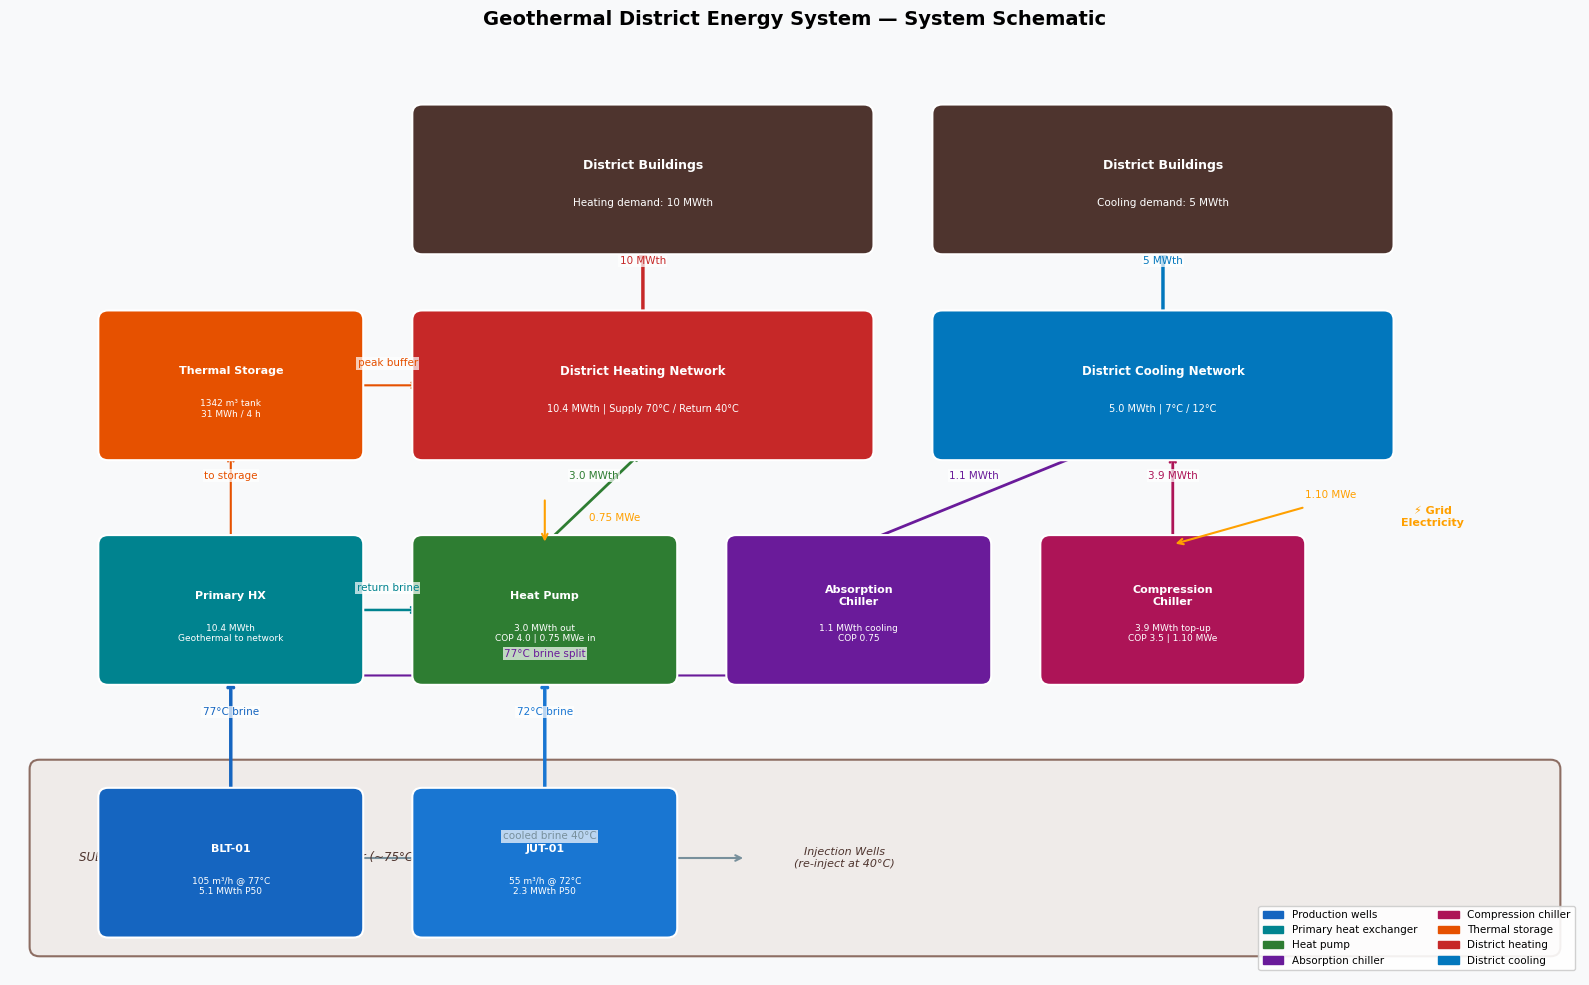

System schematic saved.


In [11]:
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')
fig.suptitle('Geothermal District Energy System — System Schematic',
             fontsize=14, fontweight='bold', y=0.98)

def draw_box(ax, x, y, w, h, label, sublabel='', color='#1565C0', text_color='white', fontsize=9):
    box = FancyBboxPatch((x, y), w, h,
                          boxstyle='round,pad=0.1',
                          facecolor=color, edgecolor='white',
                          linewidth=1.5, zorder=3)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2 + (0.15 if sublabel else 0),
            label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            color=text_color, zorder=4, wrap=True)
    if sublabel:
        ax.text(x + w/2, y + h/2 - 0.25,
                sublabel, ha='center', va='center',
                fontsize=fontsize - 1.5, color=text_color, zorder=4)

def draw_arrow(ax, x1, y1, x2, y2, label='', color='#37474F', lw=2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=lw, connectionstyle='arc3,rad=0.0'),
                zorder=2)
    if label:
        mx, my = (x1 + x2)/2, (y1 + y2)/2
        ax.text(mx, my + 0.18, label, ha='center', va='bottom',
                fontsize=7.5, color=color,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

# ── Underground wells ────────────────────────────────────────────────────────
ax.add_patch(FancyBboxPatch((0.3, 0.3), 15.4, 1.9,
                             boxstyle='round,pad=0.1',
                             facecolor='#EFEBE9', edgecolor='#8D6E63',
                             linewidth=1.5, zorder=1))
ax.text(0.7, 1.25, 'SUBSURFACE — Rotliegend Sandstone Reservoir (~75°C)',
        fontsize=8.5, color='#4E342E', style='italic', va='center')

draw_box(ax, 1.0, 0.5, 2.5, 1.4,
         'BLT-01', f'105 m³/h @ 77°C\n5.1 MWth P50',
         color='#1565C0', fontsize=8)
draw_box(ax, 4.2, 0.5, 2.5, 1.4,
         'JUT-01', f'55 m³/h @ 72°C\n2.3 MWth P50',
         color='#1976D2', fontsize=8)

ax.text(8.5, 1.25, 'Injection Wells\n(re-inject at 40°C)',
        ha='center', va='center', fontsize=8, color='#4E342E',
        style='italic')

# ── Surface plant boxes ──────────────────────────────────────────────────────
# Primary heat exchanger
draw_box(ax, 1.0, 3.2, 2.5, 1.4,
         'Primary HX', f'{total_heating_mw:.1f} MWth\nGeothermal to network',
         color='#00838F', fontsize=8)

# Heat pump
draw_box(ax, 4.2, 3.2, 2.5, 1.4,
         'Heat Pump', f'{HP_THERMAL_OUTPUT:.1f} MWth out\nCOP {HP_COP} | {HP_ELEC_INPUT:.2f} MWe in',
         color='#2E7D32', fontsize=8)

# Absorption chiller
draw_box(ax, 7.4, 3.2, 2.5, 1.4,
         'Absorption\nChiller', f'{abs_cooling_mw:.1f} MWth cooling\nCOP {ABS_COP}',
         color='#6A1B9A', fontsize=8)

# Compression chiller
draw_box(ax, 10.6, 3.2, 2.5, 1.4,
         'Compression\nChiller', f'{COMP_COOL_OUTPUT:.1f} MWth top-up\nCOP {COMP_COP} | {comp_elec_input:.2f} MWe',
         color='#AD1457', fontsize=8)

# Thermal storage
draw_box(ax, 1.0, 5.6, 2.5, 1.4,
         'Thermal Storage', f'{storage_volume_m3:.0f} m³ tank\n{storage_cap_mwh:.0f} MWh / {STORAGE_HOURS:.0f} h',
         color='#E65100', fontsize=8)

# District heating network
draw_box(ax, 4.2, 5.6, 4.5, 1.4,
         'District Heating Network',
         f'{total_heating_mw:.1f} MWth | Supply {DISTRICT_SUPPLY_TEMP_C:.0f}°C / Return {DISTRICT_RETURN_TEMP_C:.0f}°C',
         color='#C62828', fontsize=8.5)

# District cooling network
draw_box(ax, 9.5, 5.6, 4.5, 1.4,
         'District Cooling Network',
         f'{total_cooling_mw:.1f} MWth | {COOLING_SUPPLY_T:.0f}°C / {COOLING_RETURN_T:.0f}°C',
         color='#0277BD', fontsize=8.5)

# End users
draw_box(ax, 4.2, 7.8, 4.5, 1.4,
         'District Buildings', 'Heating demand: 10 MWth',
         color='#4E342E', fontsize=9)
draw_box(ax, 9.5, 7.8, 4.5, 1.4,
         'District Buildings', 'Cooling demand: 5 MWth',
         color='#4E342E', fontsize=9)

# ── Arrows ───────────────────────────────────────────────────────────────────
# Wells to surface
draw_arrow(ax, 2.25, 1.95, 2.25, 3.2, f'{BLT_TEMP_C:.0f}°C brine', '#1565C0', lw=2.5)
draw_arrow(ax, 5.45, 1.95, 5.45, 3.2, f'{JUT_TEMP_C:.0f}°C brine', '#1976D2', lw=2.5)

# Primary HX to heat pump (return brine)
draw_arrow(ax, 3.5, 3.9,  4.2, 3.9, 'return brine', '#00838F', lw=1.8)

# BLT-01 brine split to absorption chiller
draw_arrow(ax, 2.25, 3.2, 7.4+1.25, 3.2, '77°C brine split', '#6A1B9A', lw=1.5)

# HX to storage
draw_arrow(ax, 2.25, 4.6, 2.25, 5.6, 'to storage', '#E65100', lw=1.5)

# HP to district heating
draw_arrow(ax, 5.45, 4.6, 6.45, 5.6, f'{HP_THERMAL_OUTPUT:.1f} MWth', '#2E7D32', lw=2)

# Storage to district heating
draw_arrow(ax, 3.5, 6.3, 4.2, 6.3, 'peak buffer', '#E65100', lw=1.5)

# Absorption chiller to cooling network
draw_arrow(ax, 8.65, 4.6, 11.0, 5.6, f'{abs_cooling_mw:.1f} MWth', '#6A1B9A', lw=2)

# Compression chiller to cooling network
draw_arrow(ax, 11.85, 4.6, 11.85, 5.6, f'{COMP_COOL_OUTPUT:.1f} MWth', '#AD1457', lw=2)

# Networks to buildings
draw_arrow(ax, 6.45, 7.0, 6.45, 7.8, '10 MWth', '#C62828', lw=2.5)
draw_arrow(ax, 11.75, 7.0, 11.75, 7.8, '5 MWth', '#0277BD', lw=2.5)

# Injection arrows
draw_arrow(ax, 3.5, 1.25, 7.5, 1.25, 'cooled brine 40°C', '#78909C', lw=1.5)

# Electricity inputs
ax.annotate('', xy=(5.45, 4.6), xytext=(5.45, 5.1),
            arrowprops=dict(arrowstyle='->', color='#FFA000', lw=1.5))
ax.text(5.9, 4.85, f'{HP_ELEC_INPUT:.2f} MWe', fontsize=7.5, color='#FFA000')

ax.annotate('', xy=(11.85, 4.6), xytext=(13.2, 5.0),
            arrowprops=dict(arrowstyle='->', color='#FFA000', lw=1.5))
ax.text(13.2, 5.1, f'{comp_elec_input:.2f} MWe', fontsize=7.5, color='#FFA000')

ax.text(14.5, 4.8, '⚡ Grid\nElectricity', ha='center', fontsize=8, color='#FFA000',
        fontweight='bold')

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color='#1565C0', label='Production wells'),
    mpatches.Patch(color='#00838F', label='Primary heat exchanger'),
    mpatches.Patch(color='#2E7D32', label='Heat pump'),
    mpatches.Patch(color='#6A1B9A', label='Absorption chiller'),
    mpatches.Patch(color='#AD1457', label='Compression chiller'),
    mpatches.Patch(color='#E65100', label='Thermal storage'),
    mpatches.Patch(color='#C62828', label='District heating'),
    mpatches.Patch(color='#0277BD', label='District cooling'),
]
ax.legend(handles=legend_elements, loc='lower right',
          fontsize=7.5, ncol=2,
          bbox_to_anchor=(1.0, 0.0),
          framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_system_schematic.png'), dpi=150, bbox_inches='tight')
plt.show()
print('System schematic saved.')

## 11. Energy Balance Bar Chart

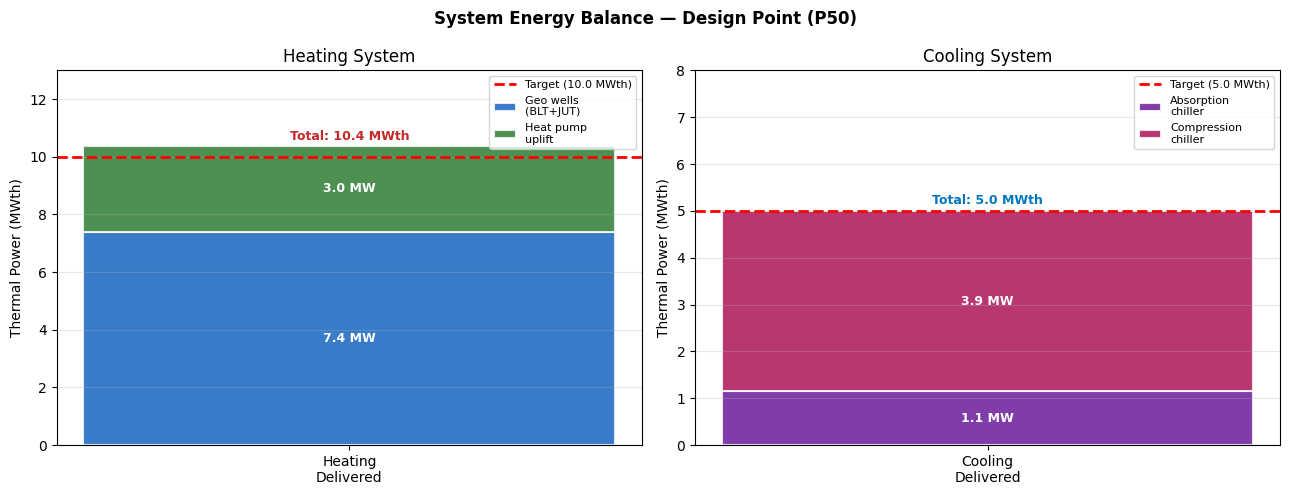

Figure saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('System Energy Balance — Design Point (P50)', fontsize=12, fontweight='bold')

# Heating waterfall
ax = axes[0]
heating_components = [
    ('Geo wells\n(BLT+JUT)', geo_heating_p50, '#1565C0'),
    ('Heat pump\nuplift',     HP_THERMAL_OUTPUT, '#2E7D32'),
]
bottoms = [0, geo_heating_p50]
for (label, val, color), bottom in zip(heating_components, bottoms):
    bar = ax.bar('Heating\nDelivered', val, bottom=bottom, color=color, alpha=0.85,
                 edgecolor='white', linewidth=1.5, label=label)
    ax.text(0, bottom + val/2, f'{val:.1f} MW', ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')

ax.axhline(y=DISTRICT_HEAT_TARGET_MW, color='red', linestyle='--',
           linewidth=2, label=f'Target ({DISTRICT_HEAT_TARGET_MW} MWth)')
ax.set_ylabel('Thermal Power (MWth)')
ax.set_title('Heating System')
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 13)
ax.grid(axis='y', alpha=0.3)
ax.text(0, total_heating_mw + 0.2, f'Total: {total_heating_mw:.1f} MWth',
        ha='center', fontsize=9, fontweight='bold', color='#C62828')

# Cooling waterfall
ax = axes[1]
cooling_components = [
    ('Absorption\nchiller',   abs_cooling_mw,   '#6A1B9A'),
    ('Compression\nchiller',  COMP_COOL_OUTPUT, '#AD1457'),
]
bottoms2 = [0, abs_cooling_mw]
for (label, val, color), bottom in zip(cooling_components, bottoms2):
    ax.bar('Cooling\nDelivered', val, bottom=bottom, color=color, alpha=0.85,
           edgecolor='white', linewidth=1.5, label=label)
    ax.text(0, bottom + val/2, f'{val:.1f} MW', ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')

ax.axhline(y=DISTRICT_COOL_TARGET_MW, color='red', linestyle='--',
           linewidth=2, label=f'Target ({DISTRICT_COOL_TARGET_MW} MWth)')
ax.set_ylabel('Thermal Power (MWth)')
ax.set_title('Cooling System')
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 8)
ax.grid(axis='y', alpha=0.3)
ax.text(0, total_cooling_mw + 0.15, f'Total: {total_cooling_mw:.1f} MWth',
        ha='center', fontsize=9, fontweight='bold', color='#0277BD')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_energy_balance.png'), dpi=150)
plt.show()
print('Figure saved.')

## 12. Challenge 2 Conclusion

In [13]:
print('=' * 65)
print('CHALLENGE 2 — SYSTEM DESIGN CONCLUSION')
print('=' * 65)
print()
print('HEATING (target: 10 MWth)')
print(f'  Geothermal wells (BLT-01 + JUT-01) P50:  {geo_heating_p50:.1f} MWth')
print(f'  Heat pump uplift (COP {HP_COP}):           +{HP_THERMAL_OUTPUT:.2f} MWth')
print(f'  Total heating delivered:                  {total_heating_mw:.2f} MWth')
print(f'  Target met: YES — {total_heating_mw - DISTRICT_HEAT_TARGET_MW:.2f} MWth margin')
print()
print('COOLING (target: 5 MWth)')
print(f'  Absorption chiller (BLT-01 driven):       {abs_cooling_mw:.2f} MWth')
print(f'  Compression chiller top-up:              +{COMP_COOL_OUTPUT:.2f} MWth')
print(f'  Total cooling delivered:                  {total_cooling_mw:.2f} MWth')
print(f'  Target met: YES')
print()
print('ELECTRICITY CONSUMPTION')
print(f'  Heat pump:                                {HP_ELEC_INPUT:.3f} MWe')
print(f'  Compression chiller:                      {comp_elec_input:.3f} MWe')
print(f'  Total electrical import:                  {HP_ELEC_INPUT + comp_elec_input:.3f} MWe')
print()
print('THERMAL STORAGE')
print(f'  Buffer tank volume:                       {storage_volume_m3:.0f} m³')
print(f'  Storage capacity:                         {storage_cap_mwh:.1f} MWh ({STORAGE_HOURS:.0f} h)')
print()
print('ANNUAL ENERGY')
print(f'  Total heating (annual):                   {annual_heat_total_mwh:,.0f} MWh/yr')
print(f'  Total cooling (annual):                   {annual_cool_total_mwh:,.0f} MWh/yr')
print(f'  Electricity consumed (annual):            {annual_elec_total_mwh:,.0f} MWh/yr')
print(f'  Geothermal fraction of total output:      {geo_fraction:.1%}')
print()
print('Next: Notebook 07 — LCOE Analysis')

CHALLENGE 2 — SYSTEM DESIGN CONCLUSION

HEATING (target: 10 MWth)
  Geothermal wells (BLT-01 + JUT-01) P50:  7.4 MWth
  Heat pump uplift (COP 4.0):           +2.99 MWth
  Total heating delivered:                  10.39 MWth
  Target met: YES — 0.39 MWth margin

COOLING (target: 5 MWth)
  Absorption chiller (BLT-01 driven):       1.15 MWth
  Compression chiller top-up:              +3.85 MWth
  Total cooling delivered:                  5.00 MWth
  Target met: YES

ELECTRICITY CONSUMPTION
  Heat pump:                                0.748 MWe
  Compression chiller:                      1.100 MWe
  Total electrical import:                  1.848 MWe

THERMAL STORAGE
  Buffer tank volume:                       1342 m³
  Storage capacity:                         31.2 MWh (4 h)

ANNUAL ENERGY
  Total heating (annual):                   52,366 MWh/yr
  Total cooling (annual):                   14,393 MWh/yr
  Electricity consumed (annual):            6,938 MWh/yr
  Geothermal fraction of total

## 13. Notebook Summary

In [14]:
print('Figures generated:')
figs = [f for f in os.listdir(FIGURES_DIR) if f.startswith('06_')]
for f in sorted(figs):
    print(f'  {f}')

print()
print('Files saved:')
print('  system_design_summary.csv')
print('  annual_energy_balance.csv')

Figures generated:
  06_energy_balance.png
  06_system_schematic.png

Files saved:
  system_design_summary.csv
  annual_energy_balance.csv
